In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
SMALL_SIZE = 14
MEDIUM_SIZE = 14
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [4]:
results05__user_10_mec5 = pd.read_csv("results/results05__user_10_mec5.csv")
results05__user_100_mec5 = pd.read_csv("results/results05__user_100_mec5.csv")
results05__user_150_mec5 = pd.read_csv("results/results05__user_150_mec5.csv")
results05__user_500_mec5 = pd.read_csv("results/results05__user_500_mec5.csv")
results05__user_1000_mec5 = pd.read_csv("results/results05__user_1000_mec5.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'results/results05__user_10_mec5.csv'

In [5]:
results05__user_10_mec5.head()

,Unnamed: 0,greedy_mean_scores,greedy_mean_task,greedy_mean_engery,greedy_sum_task,greedy_sum_engery,dqn_mean_scores,dqn_mean_task,dqn_mean_energy,dqn_sum_task,dqn_sum_engery
0,0,770.7315,0.503250,2.551781,503.25,3.406843,395.4089,0.68010,21.348325,680.10,4.329364
1,1,772.0314,0.503380,2.547034,503.38,3.406035,920.6291,0.77873,10.216190,778.73,4.009289
2,2,743.5854,0.507515,2.530702,483.44,3.385330,1114.5107,0.81263,8.511846,812.63,3.930024
3,3,769.7787,0.503050,2.548189,503.05,3.406232,1173.8817,0.82438,4.083148,824.38,3.610995
4,4,776.5766,0.507050,2.554500,507.05,3.407306,1207.8617,0.83143,4.187082,831.43,3.621912


In [6]:
plt.rcParams["figure.figsize"] = (8,6)
def plot_models_performance(data1,data2,greedy="",dqn="", y_label="Rewards",file_name="rwards_cpm.eps"):
#     Random = data['random']
    Greedy1 = data1[greedy]
    DQN1 = data1[dqn]
    Greedy2 = data2[greedy]
    DQN2 = data2[dqn]

    # Create count of the number of epochs
    epoch_count = range(1, len(Greedy1) + 1)
    epoch_count = np.array(list(epoch_count))*100

    # Visualize loss history
    plt.plot(epoch_count, Greedy1, 'kD--',linewidth=2.0)
    plt.plot(epoch_count, Greedy2, 'rx--',linewidth=2.0)
    plt.plot(epoch_count, DQN1, 'b^--',linewidth=2.0)
    plt.plot(epoch_count, DQN2, 'go--',linewidth=2.0)

    plt.legend(['Greedy 10 Users', "Greedy 1000 Users", "E2E_DQN 10 Users","E2E_DQN 1000 Users"])
    plt.xlabel('epochs')
    plt.ylabel(y_label)
    
    plt.savefig("images/"+file_name,dpi=200,format = "eps")
    plt.show()

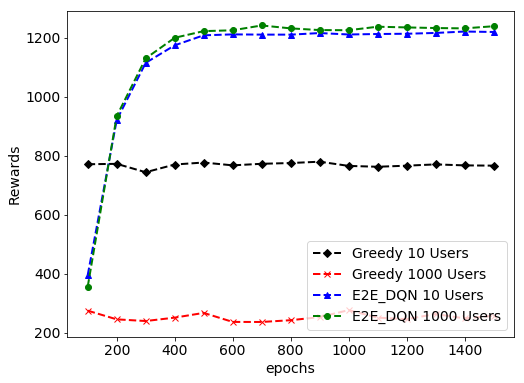

In [7]:
plot_models_performance(results05__user_10_mec5,results05__user_1000_mec5,
                        greedy='greedy_mean_scores',dqn='dqn_mean_scores')

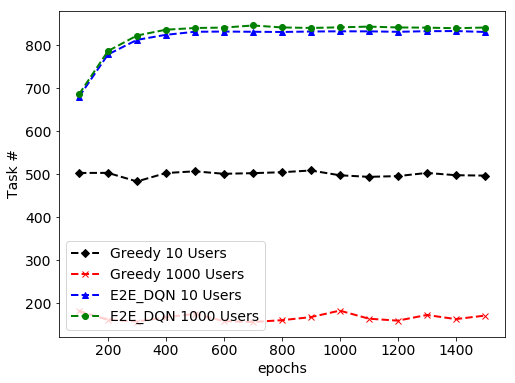

In [8]:
plot_models_performance(results05__user_10_mec5,results05__user_1000_mec5,
                        greedy='greedy_sum_task',dqn='dqn_sum_task',
                       y_label="Task #",file_name="task_cpm.eps")

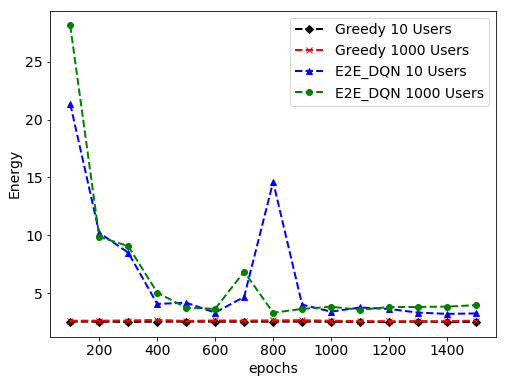

In [9]:
plot_models_performance(results05__user_10_mec5,results05__user_1000_mec5,
                        greedy='greedy_mean_engery',dqn='dqn_mean_energy',
                       y_label="Energy",file_name="energy_cpm.eps")

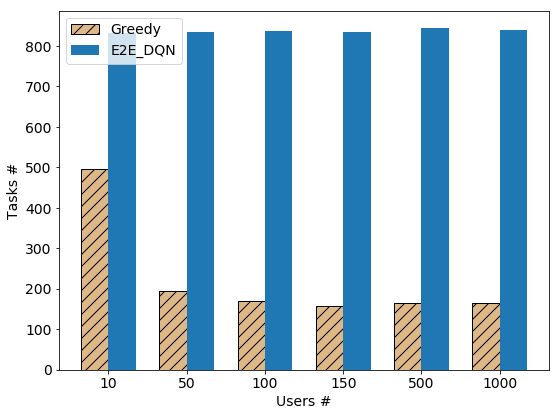

In [10]:
labels = ['10', '50', '100','150', '500', '1000']
greedy = [497.06, 194.66, 169.23, 158.08, 166.06,166]
dqn = [830.99, 833.29, 836.48, 834.66, 845.04,840]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, greedy, width, label='Greedy',color='burlywood', edgecolor='k', hatch="//")
rects2 = ax.bar(x + width/2, dqn, width, label='E2E_DQN')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Tasks #')
ax.set_xlabel('Users #')
# ax.set_title('Scores by group and gender')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
       
autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.savefig("images/user_no_task_cmp.eps",dpi=200,format = "eps")
plt.show()

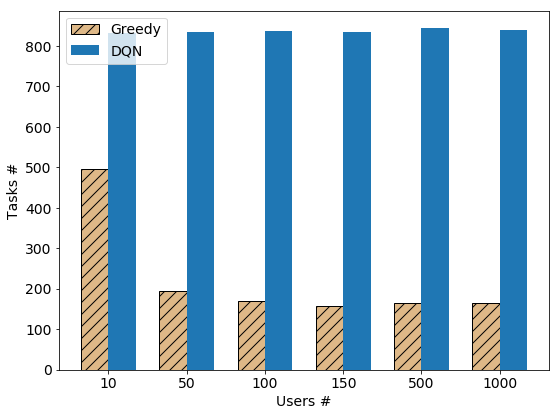

In [11]:
labels = ['10', '50', '100','150', '500', '1000']
greedy = [497.06, 194.66, 169.23, 158.08, 166.06,166]
dqn = [830.99, 833.29, 836.48, 834.66, 845.04,840]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, greedy, width, label='Greedy',color='burlywood', edgecolor='k', hatch="//")
rects2 = ax.bar(x + width/2, dqn, width, label='DQN')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Tasks #')
ax.set_xlabel('Users #')
# ax.set_title('Scores by group and gender')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
       
autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.savefig("images/user_no_task_cmp.eps",dpi=200,format = "eps")
plt.show()

## Converge

In [12]:
score_user_1000_mec5 = pd.read_csv("results/score05__user_1000_mec5.csv")

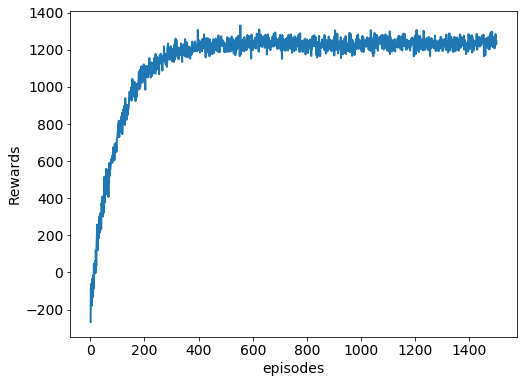

In [13]:
def plot_score(data, y_label="Rewards"):
#     Random = data['random']
    # Create count of the number of epochs
    epoch_count = range(1, len(data) + 1)
#     epoch_count = np.array(list(epoch_count))*100

    # Visualize loss history
    plt.plot(epoch_count, data,linewidth=2.0)
#     plt.plot(epoch_count, Greedy2, 'rx--',linewidth=2.0)

#     plt.legend(['Greedy 10 Users', "Greedy 1000 Users", "DQN 10 Users","DQN 1000 Users"])
    plt.xlabel('episodes')
    plt.ylabel(y_label)
    
    plt.savefig('images/converge.eps',dpi=200,format = "eps")
    plt.show()
plot_score(score_user_1000_mec5.socores)